In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

plt.style.use("ggplot")

In [4]:


nav_df = pd.read_csv(
    r"D:\Projects\mutual_fund_analysis\data\cleaned\cleaned_nav.csv"
)

txn_df = pd.read_csv(
    r"D:\Projects\mutual_fund_analysis\data\cleaned\cleaned_transactions.csv"
)

In [9]:
print(nav_df.columns)

print(txn_df.columns)

Index(['amfi_code', 'date', 'nav'], dtype='str')
Index(['investor_id', 'transaction_date', 'amfi_code', 'transaction_type',
       'amount_inr', 'state', 'city', 'city_tier', 'age_group', 'gender',
       'annual_income_lakh', 'payment_mode', 'kyc_status'],
      dtype='str')


In [12]:
print(nav_df.columns)

print(txn_df.columns)

Index(['amfi_code', 'date', 'nav'], dtype='str')
Index(['investor_id', 'transaction_date', 'amfi_code', 'transaction_type',
       'amount_inr', 'state', 'city', 'city_tier', 'age_group', 'gender',
       'annual_income_lakh', 'payment_mode', 'kyc_status'],
      dtype='str')


In [13]:
nav_df["date"] = pd.to_datetime(
    nav_df["date"]
)

txn_df["transaction_date"] = pd.to_datetime(
    txn_df["transaction_date"]
)

In [14]:
txn_df.rename(
    columns={
        "transaction_date": "date"
    },
    inplace=True
)

In [15]:
df = pd.merge(
    txn_df,
    nav_df,
    on=["amfi_code", "date"],
    how="left"
)

In [16]:
print(df.head())

print(df.shape)

  investor_id       date  amfi_code transaction_type  amount_inr        state  \
0   INV003054 2024-01-01     119092              SIP        1834    Telangana   
1   INV002952 2024-01-01     148567       Redemption      392882       Punjab   
2   INV003420 2024-01-01     118636              SIP         912      Haryana   
3   INV003436 2024-01-01     118634              SIP        1102  Maharashtra   
4   INV004691 2024-01-01     119094          Lumpsum        8682        Delhi   

        city city_tier age_group  gender  annual_income_lakh payment_mode  \
0  Hyderabad       T30       56+  Female                77.1          UPI   
1   Amritsar       B30     18-25    Male                 7.1       Cheque   
2  Faridabad       B30     36-45    Male                47.2      Mandate   
3     Mumbai       T30     36-45  Female                54.4       Cheque   
4      Noida       T30     26-35    Male                14.5  Net Banking   

  kyc_status       nav  
0   Verified   52.7328  


In [17]:
df["units"] = (
    df["amount_inr"] / df["nav"]
)

In [18]:
df = df.sort_values(
    by=["amfi_code", "date"]
)

df["previous_nav"] = (
    df.groupby("amfi_code")["nav"]
    .shift(1)
)

df["returns_percentage"] = (
    (df["nav"] - df["previous_nav"])
    / df["previous_nav"]
) * 100

In [19]:
df = df.dropna()

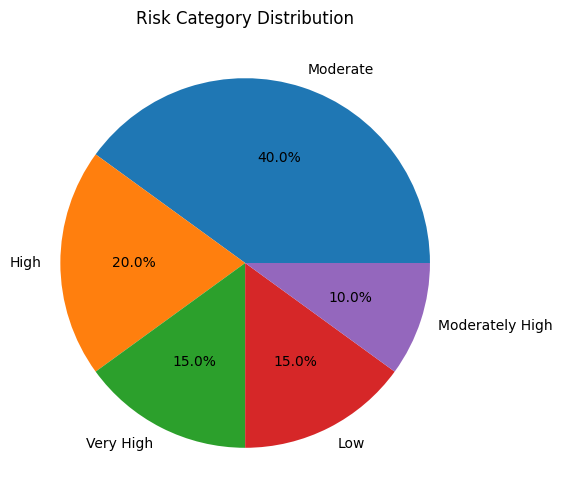

In [7]:
risk_counts = df['risk_category'].value_counts()

plt.figure(figsize=(6,6))
risk_counts.plot(kind='pie', autopct='%1.1f%%')
plt.title("Risk Category Distribution")
plt.ylabel("")
plt.show()

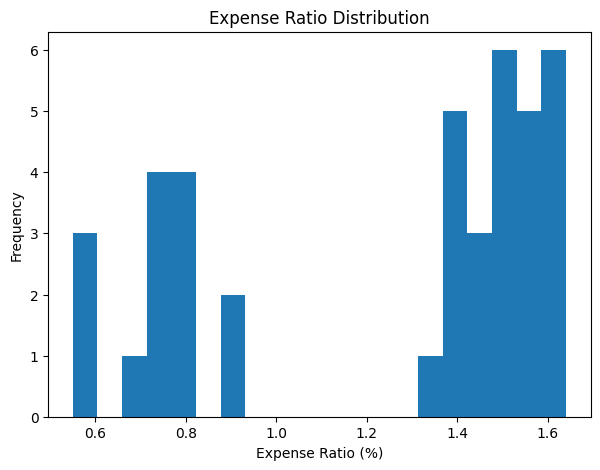

In [8]:
plt.figure(figsize=(7,5))
plt.hist(df['expense_ratio_pct'], bins=20)
plt.title("Expense Ratio Distribution")
plt.xlabel("Expense Ratio (%)")
plt.ylabel("Frequency")
plt.show()

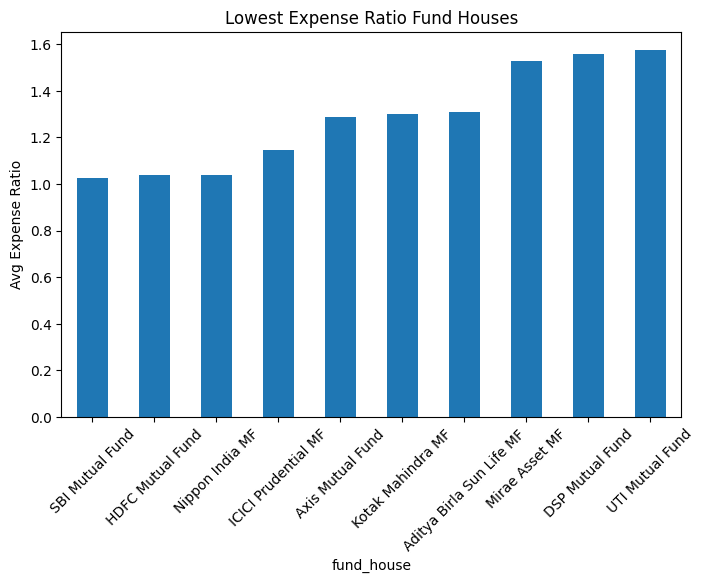

In [9]:
top_fundhouses = df.groupby('fund_house')['expense_ratio_pct'].mean().sort_values().head(10)

plt.figure(figsize=(8,5))
top_fundhouses.plot(kind='bar')
plt.title("Lowest Expense Ratio Fund Houses")
plt.ylabel("Avg Expense Ratio")
plt.xticks(rotation=45)
plt.show()

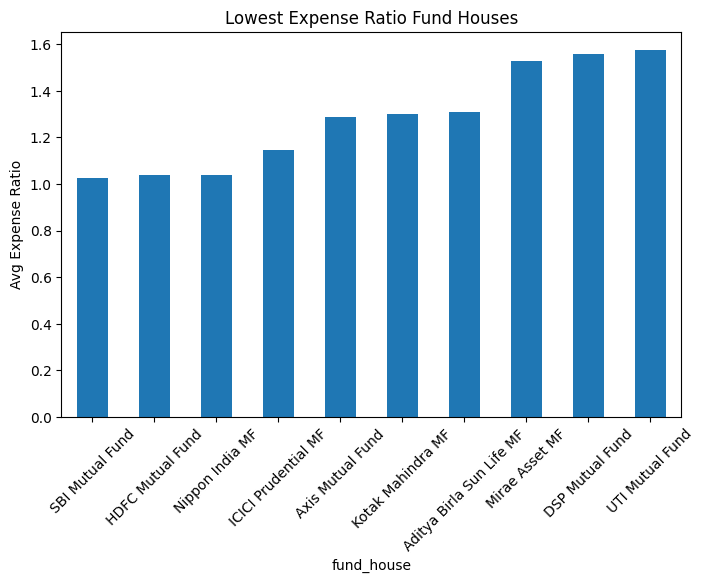

In [10]:
top_fundhouses = df.groupby('fund_house')['expense_ratio_pct'].mean().sort_values().head(10)

plt.figure(figsize=(8,5))
top_fundhouses.plot(kind='bar')
plt.title("Lowest Expense Ratio Fund Houses")
plt.ylabel("Avg Expense Ratio")
plt.xticks(rotation=45)
plt.show()

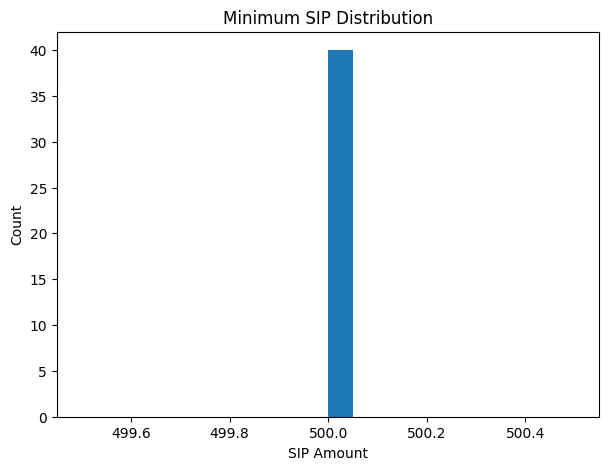

In [11]:
plt.figure(figsize=(7,5))
plt.hist(df['min_sip_amount'], bins=20)
plt.title("Minimum SIP Distribution")
plt.xlabel("SIP Amount")
plt.ylabel("Count")
plt.show()